# FRB cosmology constrain from $DM_{IGM} $

Highly uncertain: $\Omega_b, f_{IGM}, \chi, \omega$ (If do wCDM cosmology)

For FRB, cosmology distance is based on the dispersion measure (DM), which defined as
$$ DM=\int_0^{D_z}\frac{n_e(l)}{1+z(l)}dl $$

DM can be splitted into multiple terms:
$$ DM=DM_{MW}+DM_{halo}+DM_{IGM}+\frac{DM_{host}+DM_{src}}{1+z}$$
where $DM_{MW}$ is the DM from the Milky Way, $DM_{halo}$ is the DM from the halo, $DM_{IGM}$ is the DM from the intergalactic medium, $DM_{host}$ is the DM from the host galaxy, and $DM_{src}$ is the DM from the source.

$DM_{MW}$ can be derived from model. $DM_{halo} \sim (30-80)pc \; cm^{-3}$

Most important is the IGM component:
$$ <DM_{IGM}>=\frac{3cH_0 \Omega_b }{8\pi G m_p}\int_0^z \frac{f_{IGM}\chi(z')(1+z')dz'}{E(z')}$$
Here,
$$\chi=Y_H X_{e,H}+\frac{1}{2}Y_{He} X_{e,He}$$
Recall $Y_H=1/4$ and $Y_{He}=3/4$.

According to [[Bei Zhou 2014](https://journals.aps.org/prd/abstract/10.1103/PhysRevD.89.107303)], $z\lesssim 3$, $X_{e,H}=X_{e,He}=1$; at $z\gtrsim 1.5$ $f_{IGM}\approx 90\%$; as $z\leq 0.4$ $f_{IGM}\approx (82\pm 4)\%$

H fully ionized ($\chi_{e,H}=1)$ at $ z<6 $ ([Fan 2006](https://www.annualreviews.org/content/journals/10.1146/annurev.astro.44.051905.092514)), He fully ionized ($\chi_{e,He}=1$) at $ z<2$ ([McQuinn 2009](https://ui.adsabs.harvard.edu/abs/2009ApJ...694..842M/abstract))

In [1]:
import sys
sys.path.append('../Python_scripts')
from config import *
from support import *
from cosmo_support import *

In [3]:
# From DM derive redshift. Previous project analyze code.
# from scipy import integrate

# def f_IGM(z):
#     #0.84
#     return (z>1.5)*0.9+(z<=1.5)*(0.053*z+0.82) #0.83 #according to Bei Zhou 2014 paper

# def I_IGM(z,m=O_m,la=O_L):
#     return (1.+z)*f_IGM(z)/np.sqrt(m*(1.+z)**3+la)

# def f_DM(z,a=alpha):
#     Int=integrate.quad(I_IGM,0,z)[0]
#     return 30.0+a*Int+70.0/(1.+z)

# from scipy.optimize import fsolve
# def f_z(DM_MW,n=8):
#     ''' z1=0
#     z2=3
#     E=z2-z1
#     error=1/pow(10,n)
#     while E>=error/2:
#         #print([f_DM(z1),f_DM(z2)])
#         zt=(z1+z2)/2
#         ft=f_DM(zt)-DM_MW
        
#         if(ft<0):
#             z1=zt
#         elif(ft>0):
#             z2=zt
#         else:
#             z=zt
#             break
        
#         E=z2-z1
#         z=round((z1+z2)/2,n)
#         #if(z==0):
#         #    z=0.01 '''
#     return fsolve(lambda z:f_DM(z)-DM_MW,0)[0]

# load the FRB data

In [3]:
data=pd.read_csv('../Data/FRB.csv')
data.head()

,FRB,z,DM_ext,From
0,FRB 20220204A,0.4012,509.43,Kritti
1,FRB 20220207C,0.0433,132.98,Kritti
2,FRB 20220208A,0.3510,296.65,Kritti
3,FRB 20220307B,0.2418,313.43,Kritti
4,FRB 20220310F,0.4780,366.71,Kritti


In [46]:
data_Kritti = pd.read_csv('../Data/FRB_Kritti.csv')
data_Surajit = pd.read_csv('../Data/FRB_Surajit.csv')

In [53]:
for name_Kritti in data_Kritti['FRB']:
    for name_Surajit in data_Surajit['FRB']:
        if name_Kritti == name_Surajit:
            print(name_Kritti)

FRB 20220319D
FRB 20220207C
FRB 20220509G
FRB 20220914A
FRB 20220920A
FRB 20220825A
FRB 20220307B
FRB 20221012A
FRB 20220506D
FRB 20220310F
FRB 20220418A


In [54]:
common_FRBs = [name_Kritti for name_Kritti in data_Kritti['FRB'] for name_Surajit in data_Surajit['FRB'] if name_Kritti == name_Surajit]

In [55]:
common_FRBs

['FRB 20220319D',
 'FRB 20220207C',
 'FRB 20220509G',
 'FRB 20220914A',
 'FRB 20220920A',
 'FRB 20220825A',
 'FRB 20220307B',
 'FRB 20221012A',
 'FRB 20220506D',
 'FRB 20220310F',
 'FRB 20220418A']

In [83]:
(data_Surajit[data_Surajit['FRB'] == 'FRB 20220319D']['DM_ext'])

41    45.7
Name: DM_ext, dtype: float64

In [92]:
np.float64((data_Kritti[data_Kritti['FRB'] == 'FRB 20220509G']['DM_ext']))

363.43

In [94]:
for frb in common_FRBs:
    DM_Kritti = np.float64(data_Kritti[data_Kritti['FRB'] == frb]['DM_ext'])
    DM_Surajit = np.float64(data_Surajit[data_Surajit['FRB'] == frb]['DM_ext'])
    
    print(f"For {frb}, we have:")
    print(f"DM_Kritti: {DM_Kritti}, and DM_Surajit: {DM_Surajit} \n")

For FRB 20220319D, we have:
DM_Kritti: 559.43, and DM_Surajit: 45.7 

For FRB 20220207C, we have:
DM_Kritti: 346.65, and DM_Surajit: 183.08 

For FRB 20220509G, we have:
DM_Kritti: 363.43, and DM_Surajit: 214.33 

For FRB 20220914A, we have:
DM_Kritti: -22.31, and DM_Surajit: 576.08 

For FRB 20220920A, we have:
DM_Kritti: 585.84, and DM_Surajit: 274.69 

For FRB 20220825A, we have:
DM_Kritti: 214.29, and DM_Surajit: 571.54 

For FRB 20220307B, we have:
DM_Kritti: 601.37, and DM_Surajit: 363.57 

For FRB 20221012A, we have:
DM_Kritti: 405.36, and DM_Surajit: 386.68 

For FRB 20220506D, we have:
DM_Kritti: 1347.42, and DM_Surajit: 307.87 

For FRB 20220310F, we have:
DM_Kritti: 413.0, and DM_Surajit: 416.84 

For FRB 20220418A, we have:
DM_Kritti: 395.8, and DM_Surajit: 585.65 



In [ ]:
for frb in common_FRBs:
    print(data_Kritti[frb]

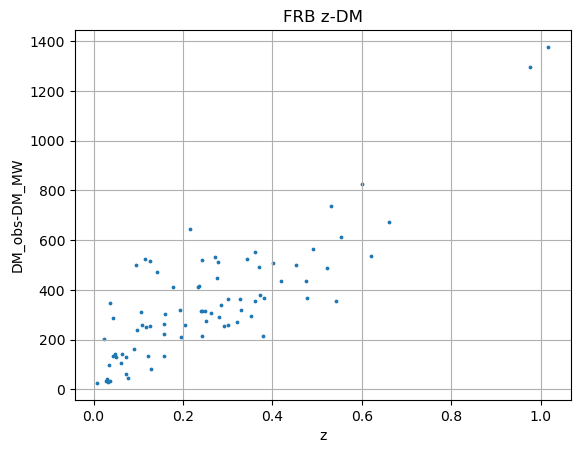

In [4]:
plt.scatter(data['z'],data['DM_ext'],s=3)  
plt.xlabel('z')
plt.ylabel('DM_obs-DM_MW')
plt.title('FRB z-DM')
plt.grid(True)
plt.show()

## The simplest case: $\chi^2$ with a single DM parameter

- For the dispersion measure:

We have contributions from the MW ${\rm DM}_{\rm MW}$, the observational limitations ${\rm DM}_{\rm obs}$, the intergalactic medium ${\rm DM}_{\rm IGM}$, the host galaxy ${\rm DM}_{\rm host}$ and potentially the source itself ${\rm DM}_{\rm host}$. Some fiducial values based on [[arXiv:1805.12265](https://arxiv.org/abs/1805.12265)] are [in pc/cm$^3$]:

$$
\sigma_{\rm MW} \sim 10, \quad \sigma_{\rm obs} \sim 1.5, \quad \sigma_{\rm IGM} \sim 100, \quad \sigma_{\rm host} \sim 30,
$$

$$
\sigma_{\rm DM_{IGM}} = \sqrt{\sigma_{\rm obs}^2+\sigma_{\rm MW}^2+\sigma_{\rm IGM}^2+\left(\frac{\sigma_{\rm host}}{1+z}\right)^2},
$$

consider uncertainty in Jun-jie Wei's paper first:

In [40]:
def sigma_DM_IGM(z, sigma_obs=1.5, sigma_MW=10, sigma_IGM=100, sigma_host=30):
    a=sigma_obs**2+sigma_MW**2+sigma_IGM**2+(sigma_host/(1+z))**2
    return np.sqrt(a)

F_fid=HUBBLE*OMEGA_BARYONS*f_IGM
print(F_fid)

2.7500474659999994


In [41]:
def DM_IGM(z, F, Om=OMEGA_MATTER, w=-1):   

    factor = 3*C_LIGHT*KM_2_MPC*F/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

In [42]:
F_array=np.linspace(0.1,10,1000)
Chi=np.zeros_like(F_array)
sigma_vec=np.vectorize(sigma_DM_IGM)
DM_vec=np.vectorize(DM_IGM)

for idx, F in enumerate(F_array):
    DM_th=DM_vec(data['z'],F)
    sigma=sigma_vec(data['z'])
    Chi[idx]=np.sum((data['DM_ext']-DM_th)**2/sigma**2)

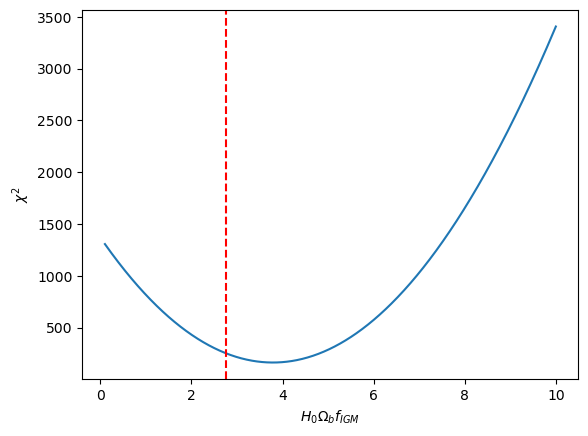

In [43]:
plt.plot(F_array, Chi)
plt.axvline(F_fid, color='r', linestyle='--')
plt.xlabel(r'$H_0 \Omega_b f_{IGM}$')
plt.ylabel(r'$\chi^2$')
plt.show()

In [44]:
np.min(Chi)

162.98356429458536

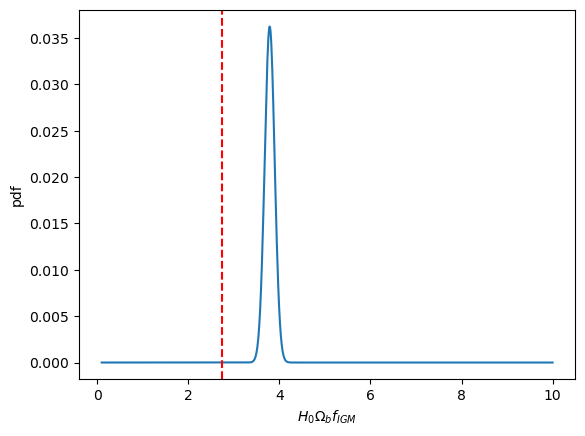

In [45]:
plt.plot(F_array, normalise(np.exp(-Chi/2)))
plt.axvline(F_fid, color='r', linestyle='--')
plt.xlabel(r'$H_0 \Omega_b f_{IGM}$')
plt.ylabel(r'pdf')
plt.show()

## Macquart. 2020 reproduce

$$ DM=DM_{MW, ISM}+DM_{MW, halo}+DM_{cosmic, IGM}+DM_{host}$$

$ DM_{halo}\approx 50 pc\,cm^{-3} $

$ DM_{MW, ISM}=30 pc\,cm^{-3} $ high Galactic latitudes

$ p_{host}(DM_{host}|\mu,\sigma_{host})=\frac{1}{\sqrt{2\pi}DM \sigma_{host}}\exp\left[-\frac{(\log DM-\mu)^2}{2\sigma_{host}^2}\right] $

median value of $ \exp^\mu$ and variance $ \exp\{(\mu+\sigma_{host}^2)/2\} (\exp\{\sigma_{host}^2\}-1)^{1/2} $

Note $ DM_{host}/(1+z) $

In [11]:
from scipy.integrate import quad_vec
def pdf_DM_host(DM, e_mu, sigma_host):
    # e^\mu with 20-200 pc cm^{-3} and \sigma_{host} in 0.2-2.0
    mu=np.log(e_mu)
    
    pdf=1.0/(sigma_host*np.sqrt(2*np.pi)*DM)*np.exp(-(np.log(DM)-mu)**2/(2*(sigma_host**2)))
    
    return pdf

def Norm_pdf_host(e_mu,sigma_host):
    try:
        int, _=quad_vec(lambda x: pdf_DM_host(x, e_mu, sigma_host), 0, 1e20)
        
        return int
    except:
        print('Normalization pdf_DM_host error')

In [12]:
print(pdf_DM_host(0.5,1,1))
print(Norm_pdf_host(1,20))

0.6274960771159244
0.989348900519691


/tmp/ipykernel_43163/3394938857.py:6: RuntimeWarning: divide by zero encountered in divide
  pdf=1.0/(sigma_host*np.sqrt(2*np.pi)*DM)*np.exp(-(np.log(DM)-mu)**2/(2*(sigma_host**2)))
/tmp/ipykernel_43163/3394938857.py:6: RuntimeWarning: divide by zero encountered in log
  pdf=1.0/(sigma_host*np.sqrt(2*np.pi)*DM)*np.exp(-(np.log(DM)-mu)**2/(2*(sigma_host**2)))
/tmp/ipykernel_43163/3394938857.py:6: RuntimeWarning: invalid value encountered in multiply
  pdf=1.0/(sigma_host*np.sqrt(2*np.pi)*DM)*np.exp(-(np.log(DM)-mu)**2/(2*(sigma_host**2)))


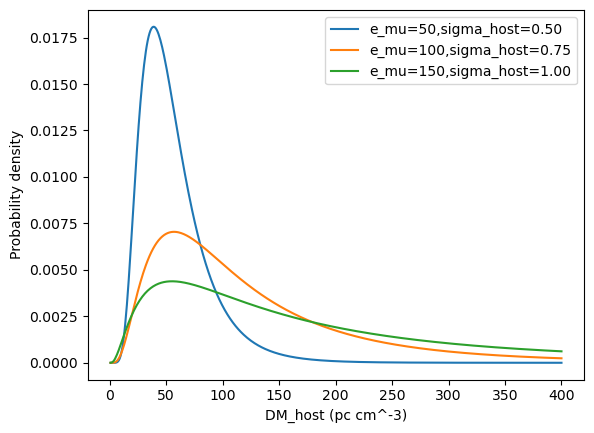

In [13]:
DM_host=np.linspace(0,400,500)
p1=pdf_DM_host(DM_host,e_mu=50,sigma_host=0.50)
p2=pdf_DM_host(DM_host,e_mu=100,sigma_host=0.75)
p3=pdf_DM_host(DM_host,e_mu=150,sigma_host=1.00)

plt.plot(DM_host,p1,label='e_mu=50,sigma_host=0.50')
plt.plot(DM_host,p2,label='e_mu=100,sigma_host=0.75')
plt.plot(DM_host,p3,label='e_mu=150,sigma_host=1.00')
plt.xlabel('DM_host (pc cm^-3)')
plt.ylabel('Probability density')
plt.legend()
plt.show()

$ p_{cosmic, IGM}(\Delta)=A\Delta^{-\beta}\exp\left(-\frac{(\Delta^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right) $

$ \sigma_{DM} $ dominated by physical variance in $DM_{cosmic}$

$\Delta=DM_{cosmic}/<DM_{cosmic}>$

$ \sigma_{DM}=Fz^{-0.5} $

Whith 3D density profile scales as $ \rho \propto r^{-\alpha} $, we have $\beta=(\alpha+1)/(\alpha-1)$

$ \alpha=3$, $\beta=3$

In [14]:
def f_sigma_DM(F, z):
    return F/np.sqrt(z)

def pdf_DM_cosmo(Delta, C_0, A, sigma, alpha=3, beta=3):
    pdf=A*(Delta**(-beta))*np.exp(-((Delta**(-alpha)-C_0)**2)/(2*(alpha**2)*(sigma**2)))
    return pdf

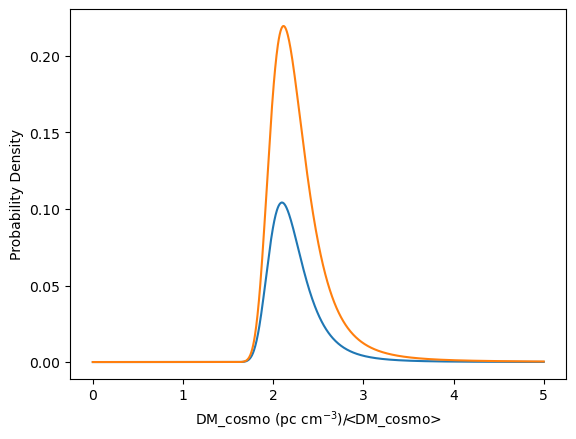

In [15]:
DM_cos=np.linspace(0.001,5,1000)
p=pdf_DM_cosmo(DM_cos, C_0=0.1, A=1, sigma=0.01)
p2=DM_cos*pdf_DM_cosmo(DM_cos, C_0=0.1, A=1, sigma=0.01)
plt.plot(DM_cos,p)
plt.plot(DM_cos,p2)
plt.xlabel('DM_cosmo (pc cm$^{-3}$)/<DM_cosmo>')
plt.ylabel('Probability Density')
plt.show()

Two constants still not known: $A $ and $ C_0$. According to the paper, $ C_0$ is constrain by the $ <x>=\int xp dx=1$. considering pdf, we also have $ \int p dx=1$, which help us to find $ C_0$ and $A$.

$ \int p_{cosmic, IGM}(x) dx=\int A x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx=1 $

$ \int x p_{cosmic, IGM}(x) dx=\int A x^{-\beta+1}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx=1 $

When we do:

$ \frac{\int x p_{cosmic, IGM}(x) dx}{\int p_{cosmic, IGM}(x) dx}=\frac{\int A x^{-\beta+1}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx}{\int A x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx}=1 $

Equavalent to: 

$ \int x \cdot p_{cosmic, IGM}(x) dx - \int p_{cosmic, IGM}(x) dx=0 $

Using this equation to do numerical calculation.

If use $ \int (x-1) p_{cosmic, IGM}(x) dx=0 $ to find C_0 will cost more time.

$A$ cancels out so we can solve for $C_0$. As for $A$, when we have $C_0$,we have:

$ A=\frac{A}{\int p_{cosmic, IGM}(x) dx}=\frac{1}{\int x^{-\beta}\exp\left(-\frac{(x^{-\alpha}-C_0)^2}{2\alpha^2 \sigma_{DM}^2}\right)dx} $

First, let's find $C_0$

In [16]:
from scipy.optimize import fsolve

def C0_sigma(sigma, alpha=3, beta=3):
    """
    Use fsolve to find C_0 when to_C_0 = 1
    
    Parameters:
    -----------
    F: float - Structure factor parameter 
    z: float - Redshift
    alpha: float - Alpha parameter
    initial_guess: float - C_0 initial guess
    
    Returns:
    --------
    float: C_0 or None if solution not found
    """
    
    def objective_function(C_0):
        result1,_= quad(lambda x: x*pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), 0, np.inf)
        result2,_= quad(lambda x: pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), 0, np.inf)
        return result1-result2
    
    try:
        initial_guess=1.0
        solution = fsolve(objective_function, [initial_guess], full_output=True)
        
        if solution[2] == 1:  # Check if solution is found
            return solution[0][0]
        else:
            print(f"find_C0 warning: sigma={sigma}")
            return None
            
    except Exception as e:
        print(f"find_C0 error, sigma={sigma}, error: {e}")
        return None

In [17]:
sigmas=np.linspace(0,1.8,1000)
sigmas=sigmas+(sigmas[2]-sigmas[1])
C0s=np.zeros_like(sigmas)
for i, sigma in enumerate(sigmas):
    C0s[i]=C0_sigma(sigma)

Text(0, 0.5, 'C_0')

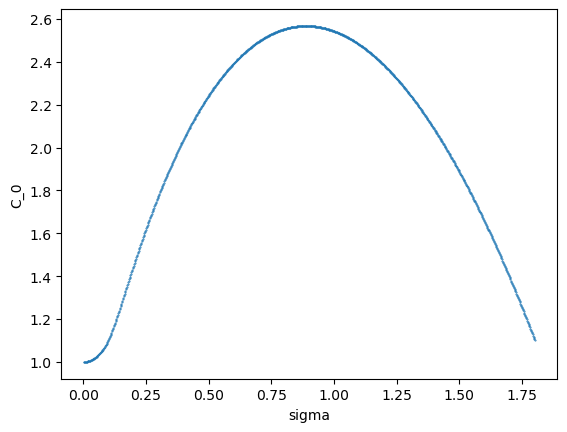

In [18]:
plt.scatter(sigmas,C0s,s=0.2)
plt.xlabel('sigma')
plt.ylabel('C_0')

In [19]:
from scipy import interpolate

def find_C0(F, z, alpha=3, beta=3, method="interpolation", sigmas=sigmas, C0s=C0s):
    """
    Use fsolve to find C_0 when to_C_0 = 1
    
    Parameters:
    -----------
    F: float - Structure factor parameter 
    z: float - Redshift
    alpha: float - Alpha parameter
    initial_guess: float - C_0 initial guess
    
    Returns:
    --------
    float: C_0 or None if solution not found
    """
    
    if (method=="interpolation"):
        sigma=f_sigma_DM(F,z)
        DM_sigma = interpolate.interp1d(sigmas, C0s, kind='cubic')
        C0 = DM_sigma(sigma)
        return C0
        
    else:
        print("Do accurate method")
    
        def objective_function(C_0):
            #return to_C_0(C_0[0], F, z, alpha) - 1
            A=1
            sigma=f_sigma_DM(F,z)
            result1,_= quad(lambda x: x*pdf_DM_cosmo(x, C_0, A, sigma, alpha, beta), 0, np.inf)
            result2,_= quad(lambda x: pdf_DM_cosmo(x, C_0, A, sigma, alpha, beta), 0, np.inf)
            return result1-result2
    
        try:
            initial_guess=1.0
            solution = fsolve(objective_function, [initial_guess], full_output=True)
        
            if solution[2] == 1:  # Check if solution is found
                return solution[0][0]
            else:
                print(f"find_C0 warning: F={F}, z={z}")
                return None
            
        except Exception as e:
            print(f"find_C0 error, F={F}, z={z}, error: {e}")
            return None

In [20]:
Fs = np.linspace(0.01, 0.5,10)
results = {}

for F in Fs:
    C_0 = find_C0(F=F, z=0.2, method="acc")
    results[F] = C_0
    print(f"For F = {F}: C_0 = {C_0}")

Do accurate method
For F = 0.01: C_0 = 1.0045183164070408
Do accurate method
For F = 0.06444444444444444: C_0 = 1.2461762326530976
Do accurate method
For F = 0.11888888888888888: C_0 = 1.6727084195353494
Do accurate method
For F = 0.17333333333333334: C_0 = 2.0110568510984304
Do accurate method
For F = 0.22777777777777777: C_0 = 2.2598800748232577
Do accurate method
For F = 0.2822222222222222: C_0 = 2.4302562360462345
Do accurate method
For F = 0.33666666666666667: C_0 = 2.530641233199334
Do accurate method
For F = 0.3911111111111111: C_0 = 2.5672039996359968
Do accurate method
For F = 0.44555555555555554: C_0 = 2.544560414160758
Do accurate method
For F = 0.5: C_0 = 2.466268439524445


In [21]:
Fs = np.linspace(0.01, 0.5,10)
results = {}

for F in Fs:
    C_0 = find_C0(F=F, z=0.2)
    results[F] = C_0
    print(f"For F = {F}: C_0 = {C_0}")

For F = 0.01: C_0 = 1.0045183163491718
For F = 0.06444444444444444: C_0 = 1.2461762326484562
For F = 0.11888888888888888: C_0 = 1.6727084194751196
For F = 0.17333333333333334: C_0 = 2.0110568510984494
For F = 0.22777777777777777: C_0 = 2.259880074823562
For F = 0.2822222222222222: C_0 = 2.43025623604639
For F = 0.33666666666666667: C_0 = 2.5306412331994066
For F = 0.3911111111111111: C_0 = 2.567203999636107
For F = 0.44555555555555554: C_0 = 2.5445604141607636
For F = 0.5: C_0 = 2.4662684395245096


In [22]:
def test(C_0,F,z):
    A=1.0
    result1,_= quad(lambda x: x*pdf_DM_cosmo(x, C_0, A, f_sigma_DM(F,z), 3,3), 0, np.inf)
    result2,_= quad(lambda x: pdf_DM_cosmo(x, C_0, A, f_sigma_DM(F,z), 3,3), 0, np.inf)
    return result1-result2

In [23]:
print(test(C_0=1.1,F=0.01,z=0.4012))

-0.0011762335464061482


In [24]:
print(find_C0(0.06332908400455114*np.sqrt(0.2),0.2))

1.0374716905206633


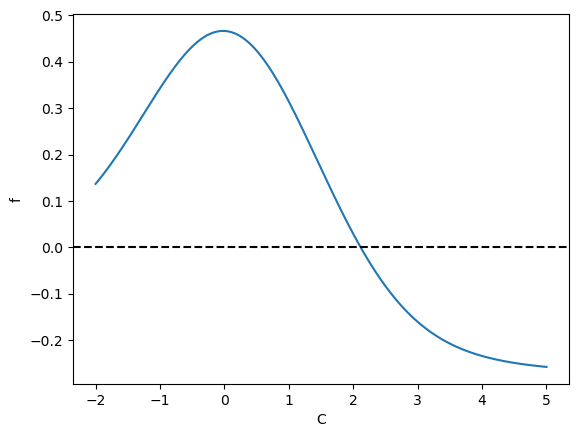

In [25]:
Cs=np.linspace(-2,5,1000)
f=np.zeros(len(Cs))+1
for i,C in enumerate(Cs):
    f[i]=test(C,F=0.3,z=0.478)
plt.plot(Cs,f)
plt.xlabel('C')
plt.ylabel('f')
plt.axhline(y=0, color='black', linestyle='--')
plt.show()

In [26]:
import timeit

In [27]:
print("\n Timing for Jiaming:")
%timeit find_C0(F=0.1, z=1)


 Timing for Jiaming:
168 µs ± 1.31 µs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


cross check

In [28]:
# zs = np.linspace(0.001, 2, 100)
# C_0_z = pd.DataFrame(zs, columns=['z'])

# for i, z in enumerate(zs):
#     C_0 = find_C0(F=0.1, z=z)
#     C_0_z.loc[i, 'C_0'] = C_0
# C_0_z.head()

In [29]:
# C_0_z.to_csv('C_0_z_v2.csv')

Now let's try to find $A$

In [30]:
def find_A(C_0, F, z, alpha=3, beta=3):
    sigma=f_sigma_DM(F,z)
    pdf, error = quad(lambda x: pdf_DM_cosmo(x, C_0, 1, sigma, alpha, beta), 0, np.inf)
    
    try:
        return 1/pdf
            
    except Exception as e:
        print(f"find_A error，pdf={pdf}, C_0={C_0}, F={F}, z={z}, error: {e}")
        return None

In [31]:
print(find_A(1.189,0.3044,1))

1.4066450703107791


Check if correct

In [32]:
z=0.2
F=0.3

C_0=find_C0(F=F,z=z)
A=find_A(C_0=C_0,F=F,z=z)
print(fr'C_0={C_0}, A={A}')

pdf,error=quad(lambda x: pdf_DM_cosmo(x, C_0, A, F, z), 0, np.inf)
print(pdf,error)

C_0=2.4703923346341106, A=0.8281161404473865
2179.6059517371064 2.64493658291311e-07


Show extend fig. 3. Double check.

In [33]:
DMs=np.linspace(40,2000,1000)
zs=np.array([0.1,0.2,0.5,1.0])
p_DM=pd.DataFrame(columns=zs)
F=0.15
vec_DM_cosmo=np.vectorize(pdf_DM_cosmo)

for z in zs:
    C_0=find_C0(F=F,z=z
                #,method="acc"
                )
    A=find_A(C_0=C_0,F=F,z=z)
    DM_mean=dispersion_measure(z=z,H0=HUBBLE,Om=OMEGA_MATTER) # need larger
    p_DM[z]=DMs*vec_DM_cosmo(Delta=DMs/DM_mean,C_0=C_0,A=A,sigma=f_sigma_DM(F,z))

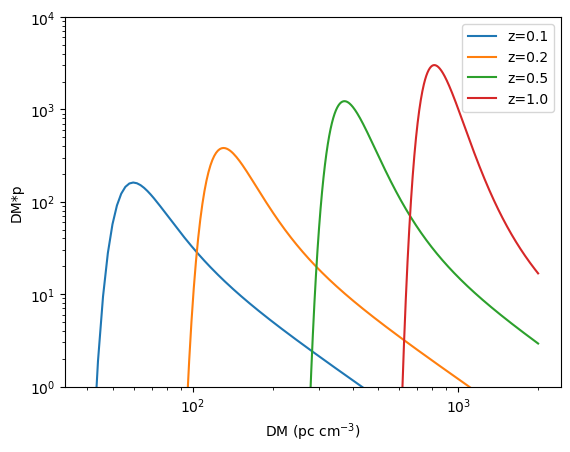

In [34]:
plt.plot(DMs,p_DM[zs[0]],label='z=0.1')
plt.plot(DMs,p_DM[zs[1]],label='z=0.2')
plt.plot(DMs,p_DM[zs[2]],label='z=0.5')
plt.plot(DMs,p_DM[zs[3]],label='z=1.0')
plt.xlabel('DM (pc cm$^{-3}$)')
plt.ylabel('DM*p')
plt.xscale('log')
plt.yscale('log')
plt.ylim(1, 10**4)
plt.legend()
plt.show()

Now let's try to find best parameters for FRBs.

Dropped rows:
              FRB  DM_
30  FRB 20171020A -3.9
41  FRB 20190425A -0.8


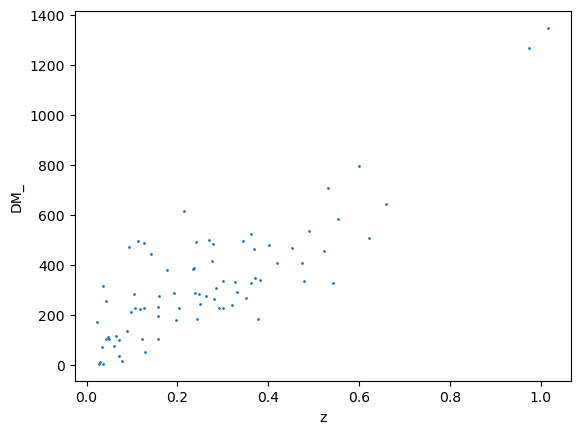

In [35]:
DM_halo=30  # In paper is 50, but Bing suggest smaller values
# DM_ISM=30 # we already have DM_MW in data

data['DM_']=data['DM_ext']-DM_halo

dropped_rows = data[data['DM_'] < 0]

# 2. Print FRB values of dropped rows if any exist
if not dropped_rows.empty:
    print("Dropped rows:")
    print(dropped_rows[['FRB', 'DM_']])
else:
    print("No rows with DM_ < 0 found to drop")

# 3. Keep only rows where DM_ext >= 0
data = data[data['DM_'] >= 0]

plt.scatter(data['z'],data['DM_'],s=1)
plt.ylabel('DM_')
plt.xlabel('z')
plt.show()

In [36]:
data.head()

,FRB,z,DM_ext,DM_
0,FRB 20220204A,0.4012,509.43,479.43
1,FRB 20220207C,0.0433,132.98,102.98
2,FRB 20220208A,0.3510,296.65,266.65
3,FRB 20220307B,0.2481,313.43,283.43
4,FRB 20220310F,0.4780,366.71,336.71


$ DM'_{FRB}=DM_{FRB}-DM_{MW, ISM}-DM_{MW, halo}=DM_{host}+DM_{cosmic} $

$ P_i(DM'_{FRB,i}|z_i)=\int_0^{DM'_{FRB,i}} p_{host}(DM_{host}|\mu, \sigma_{host})p_{cosmic}(DM'_{FRB,i}-DM_{host}, z_i)d DM_{host}$

$ \mathcal{L} = \prod_{i=1}^{N_{\text{FRBs}}} P_i(\text{DM}'_{\text{FRB}} | z_i) $


Note actually:

$ DM'_{FRB}=DM_{FRB}-DM_{MW, ISM}-DM_{MW, halo}=\frac{DM_{host}}{1+z}+DM_{cosmic} $

so:

$ P_i(DM'_{FRB,i}|z_i)=\int_0^{DM'_{FRB,i}} p_{host}(DM_{host}|\mu, \sigma_{host})p_{cosmic}(DM'_{FRB,i}-\frac{DM_{host}}{1+z_i}, z_i)d DM_{host}$

In [37]:
def DM_IGM_O_bh_70(z, O_bh_70, Om=OMEGA_MATTER ,w=-1):
    """
    Function of the DM formula, 
    eq. (12) in [arXiv:1805.12265].
    
    Input
    ----------
    z : redshift
    
    H0 : Hubble constant [km/s/Mpc]
    
    Om : Omega matter
    
    w : DE EoS parameter (w=-1 for Λ)
    
    Output
    ---------
    DM : Dispersion measure [pc/cm^3]
    """    
    
    O_bH_0=O_bh_70*70

    factor = 3*C_LIGHT*KM_2_MPC*O_bH_0*f_IGM/(8*PI*G_NEWTON*M_PROTON)*(7/8)
    integral = quad(dDM_integrand_w, 0, z, args=(Om, w))[0]
    
    unit_transform = DM_2_PCCM3
    
    DM = unit_transform*factor*integral
    
    return DM

In [38]:
def calculate_dm_probability(DM_frb,z,F,O_bh_70,sigma_host,e_mu):
    """
    Calculate the probability of DM_FRB given various cosmological parameters
    
    Parameters:
    -----------
    DM_frb : float
        The observed DM_FRB value
    z : float
        Redshift
    F : float
        Structure factor parameter
    O_bh_70 : float
        Baryon density parameter
    sigma_host : float
        Standard deviation of host DM distribution
    e_mu : float
        Mean of host DM distribution
    
    Returns:
    --------
    float
        The calculated probability
    """

    # def integrand(DM_host):
    #     # Calculate p_host at the current dm_host value
    #     p_host_val = pdf_DM_host(DM_host, e_mu, sigma_host)
        
    #     # Calculate p_cosmic at (DM_FRB - DM_host)
    #     C_0=find_C0(F=F, z=z)
        
    #     if C_0 is None:
    #         print(f"Error: find_C0 C_0 is None, when F={F}, z={z}")
    #         return 0.0
            
    #     try:
    #         A = find_A(C_0=C_0, F=F, z=z)
    #     except:
    #         print(f"Error: find_A, when F={F}, z={z}")
    #         return 0.0
        
    #     if A is None:
    #         print(f"Error: C_0={C_0} or A={A}, when F={F}, z={z}")
    #         return 0.0
        
    #     # Calculate delta parameter
    #     delta=DM_frb - DM_host #/(1+z)
    #     delta=delta/DM_IGM_O_bh_70(z=z,O_bh_70=O_bh_70)
    #     p_cosmic_val = pdf_DM_cosmo(Delta=delta, C_0=C_0, A=A, sigma=f_sigma_DM(F,z))
        
    #     # if (p_host_val>=1) or (p_cosmic_val>=1):
    #     #     print(
    #     #         [F,z,p_cosmic_val])
        
    #     return p_host_val * p_cosmic_val
    
    def integrand(DM_IGM):
        # Calculate p_host at the current dm_host value
        # p_host_val = pdf_DM_host(DM_host, e_mu, sigma_host)
        
        # Calculate p_cosmic at (DM_FRB - DM_host)
        C_0=find_C0(F=F, z=z)
        
        if C_0 is None:
            print(f"Error: find_C0 C_0 is None, when F={F}, z={z}")
            return 0.0
            
        try:
            A = find_A(C_0=C_0, F=F, z=z)
        except:
            print(f"Error: find_A, when F={F}, z={z}")
            return 0.0
        
        if A is None:
            print(f"Error: C_0={C_0} or A={A}, when F={F}, z={z}")
            return 0.0
        
        # Calculate delta parameter
        delta=DM_IGM/DM_IGM_O_bh_70(z=z,O_bh_70=O_bh_70)
        p_cosmic_val = pdf_DM_cosmo(Delta=delta, C_0=C_0, A=A, sigma=f_sigma_DM(F,z))
        
        DM_host=(DM_frb - DM_IGM)*(1+z)
        p_host_val = pdf_DM_host(DM_host, e_mu, sigma_host)
        
        # if (p_host_val>=1) or (p_cosmic_val>=1):
        #     print(
        #         [F,z,p_cosmic_val])
        
        return p_host_val * p_cosmic_val
    
    # Perform the integration from 0 to DM_FRB
    result, error = quad(integrand, 0, DM_frb)#*(1+z))
    
    return result

In [39]:
F_array=np.linspace(0.01,0.5,10)
O_bh_70_array=np.linspace(0.015,0.095,10)
sigma_host_array=np.linspace(0.2,2.0,5)
e_mu_array=np.linspace(20,200,5)

F_4D, O_bh_70_4D, sigma_host_4D, e_mu_4D = np.meshgrid(F_array, O_bh_70_array, sigma_host_array, e_mu_array)

F_h, h_F = np.meshgrid(F_array, O_bh_70_array)
F_sigma, sigma_F = np.meshgrid(F_array, sigma_host_array)
F_e_mu, e_mu_F = np.meshgrid(F_array, e_mu_array)

h_sigma, sigma_h = np.meshgrid(O_bh_70_array, sigma_host_array)
h_e_mu, e_mu_h = np.meshgrid(O_bh_70_array, e_mu_array)

sigma_e_mu, e_mu_sigma = np.meshgrid(sigma_host_array, e_mu_array)

print(fr'Shape of F_4D: {F_4D.shape}, O_bh_70_4D: {O_bh_70_4D.shape}, sigma_host_4D: {sigma_host_4D.shape}, e_mu_4D: {e_mu_4D.shape}')
print(fr'Shape of F_h: {F_h.shape}, h_F: {h_F.shape}, F_sigma: {F_sigma.shape}, sigma_F: {sigma_F.shape}, F_e_mu: {F_e_mu.shape}, e_mu_F: {e_mu_F.shape}')

Shape of F_4D: (10, 10, 5, 5), O_bh_70_4D: (10, 10, 5, 5), sigma_host_4D: (10, 10, 5, 5), e_mu_4D: (10, 10, 5, 5)
Shape of F_h: (10, 10), h_F: (10, 10), F_sigma: (5, 10), sigma_F: (5, 10), F_e_mu: (5, 10), e_mu_F: (5, 10)


In [40]:
C_0=find_C0(F=0.1,z=0.4755)
A=find_A(find_C0(F=0.1,z=0.4755),F=0.1,z=0.4755)

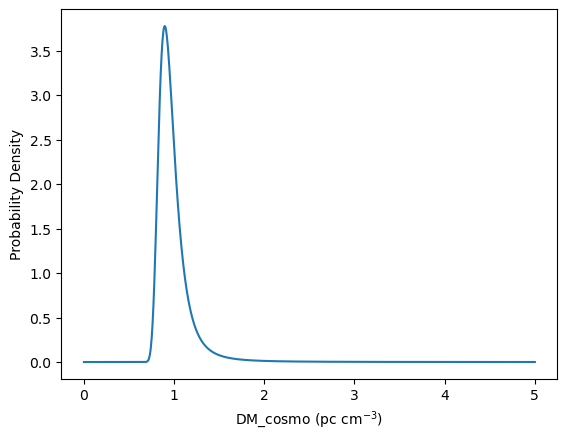

In [41]:
DM_cos=np.linspace(0.001,5,1000)
sigma=f_sigma_DM(F=0.1,z=0.4755)
p=pdf_DM_cosmo(DM_cos, C_0=C_0, A=A, sigma=sigma)
plt.plot(DM_cos,p)
plt.xlabel('DM_cosmo (pc cm$^{-3}$)')
plt.ylabel('Probability Density')
plt.show()

In [42]:
print(np.sum(p)*(DM_cos[2]-DM_cos[1]))

0.999055142133939


In [43]:
print(calculate_dm_probability(DM_frb=509.27,z=0.4755,F=0.2,O_bh_70=0.06,sigma_host=0.3,e_mu=60))

1.4889088572017195


In [44]:
import timeit

def timer_calculate_dm_probability():
    return calculate_dm_probability(DM_frb=300, z=0.2, F=0.1, O_bh_70=0.05, sigma_host=0.25, e_mu=50)

# time 
execution_time = timeit.timeit(timer_calculate_dm_probability, number=1)
print(f"calculate_dm_probability time: {execution_time:.6f} seconds")

calculate_dm_probability time: 0.127038 seconds


For Macquart test

In [45]:
data=pd.read_csv('../data/FRB_Macquart_org.csv') #exactly 5 golden FRBs in Macquart paper, DM_ext=DM-30-50, which is DM_MW and DM_ISM in their paper
data.head()

,FRB,z,DM_ext,DM
0,FRB 20180924,0.3214,281.42,361.42
1,FRB 20181112,0.4755,509.27,589.27
2,FRB 20190102,0.2910,283.60,363.60
3,FRB 20190608,0.1178,258.70,338.70
4,FRB 20190711,0.5220,513.10,593.10


In [45]:
from tqdm import tqdm

posterior_4D = np.zeros_like(F_4D)
# Calculate total iterations for progress bar
total_iterations = len(F_array) * len(O_bh_70_array) * len(sigma_host_array) * len(e_mu_array)

# Create flattened parameter combinations
param_combinations = [
    (F, O_bh70, sigma_host, e_mu)
    for F in F_array
    for O_bh70 in O_bh_70_array
    for sigma_host in sigma_host_array
    for e_mu in e_mu_array
]

# Initialize progress bar
pbar = tqdm(total=total_iterations, desc='Computing posteriors')

# Iterate through parameter combinations
for idx, (F, O_bh70, sigma_host, e_mu) in enumerate(param_combinations):
    # Initialize the total probability
    prob_total = 1.0
    
    # Calculate and accumulate probabilities for each FRB
    for _, row in data.iterrows():
        prob = calculate_dm_probability(
            DM_frb=row['DM_ext'],
            z=row['z'],
            F=F,
            O_bh_70=O_bh70,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
        prob_total *= prob
    
    # Calculate indices for 4D array
    i = idx // (len(O_bh_70_array) * len(sigma_host_array) * len(e_mu_array))
    j = (idx % (len(O_bh_70_array) * len(sigma_host_array) * len(e_mu_array))) // (len(sigma_host_array) * len(e_mu_array))
    k = (idx % (len(sigma_host_array) * len(e_mu_array))) // len(e_mu_array)
    l = idx % len(e_mu_array)
    
    # Store result
    posterior_4D[i,j,k,l] = prob_total
    
    # Update progress bar
    pbar.update(1)
    
    # Optional: Add parameter values to progress bar description
    pbar.set_description(f'F={F:.2f}, O_bh70={O_bh70:.2f}, σ={sigma_host:.2f}, μ={e_mu:.2f}')

# Close progress bar
pbar.close()

F=0.12, O_bh70=0.10, σ=1.55, μ=200.00:  30%|██▉       | 745/2500 [12:02<14:21,  2.04it/s]  /tmp/ipykernel_43163/3900486896.py:93: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  result, error = quad(integrand, 0, DM_frb)#*(1+z))
F=0.50, O_bh70=0.01, σ=1.10, μ=20.00:  90%|█████████ | 2261/2500 [1:08:16<04:23,  1.10s/it]   

In [46]:
# # Initialize posterior_4D array for storing results
# posterior_4D = np.zeros_like(F_4D)

# # Iterate through all parameter combinations
# for i, F in enumerate(F_array):
#     for j, O_bh70 in enumerate(O_bh_70_array):
#         for k, sigma_host in enumerate(sigma_host_array):
#             for l, e_mu in enumerate(e_mu_array):
#                 # Initialize the total probability for current parameter combination
#                 prob_total = 1.0  # or 0.0 if you want to sum instead of multiply
               
#                 # Calculate and accumulate probabilities for each FRB
#                 for _, row in data.iterrows():
#                     prob = calculate_dm_probability(
#                         #DM_frb=row['DM_'],     # Use DM_ column as DM_frb
#                         DM_frb=row['DM_ext'],
#                         z=row['z'],            # Use z column as redshift
#                         F=F,                   # Structure factor from parameter space
#                         O_bh_70=O_bh70,        # Baryon density from parameter space
#                         sigma_host=sigma_host, # Host DM standard deviation from parameter space
#                         e_mu=e_mu             # Host DM mean from parameter space
#                     )
#                     # Accumulate probability (multiply or add)
#                     prob_total *= prob  # or prob_total += prob
#                     # print(f"DM, z = {row['DM_ext']},{row['z']}, F, O_bh_70, sigma_host, e_mu={F},{O_bh70}, {sigma_host}, {e_mu}, prob={prob}, prob_tot={prob_total}",end='\r')
                
#                 # Store the accumulated result in posterior_4D
#                 posterior_4D[i,j,k,l] = prob_total
                
#             # print(f"DM, z = {i},{j},{k},{l}",end='\r')

In [50]:
posterior_4D_tot=np.sum(posterior_4D)
posterior_4D=posterior_4D/posterior_4D_tot
print(posterior_4D_tot)

1.0000000000000002


Understand PDF, CDF, PPF for chi2

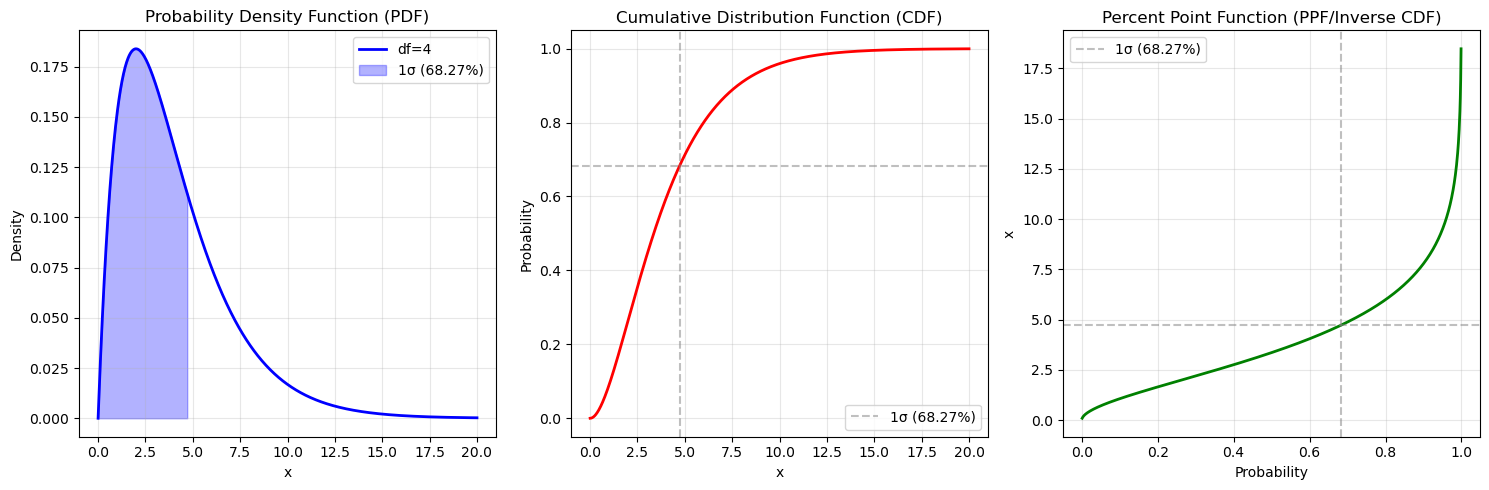


Critical values for different sigma levels (df=4):
1σ (68.27%): 4.720
2σ (95.45%): 9.716
3σ (99.73%): 16.251


In [ ]:
from scipy import stats

# Create figure with three subplots
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# Generate x values for plotting
x = np.linspace(0, 20, 1000)
p = np.linspace(0.001, 0.999, 1000)  # for PPF, avoid 0 and 1

# Plot PDF (Probability Density Function)
df = 4  # degrees of freedom
pdf = stats.chi2.pdf(x, df)
ax1.plot(x, pdf, 'b-', lw=2, label=f'df={df}')
ax1.fill_between(x, pdf, where=(x <= stats.chi2.ppf(0.6827, df)), 
                 alpha=0.3, color='blue', label='1σ (68.27%)')
ax1.set_title('Probability Density Function (PDF)')
ax1.set_xlabel('x')
ax1.set_ylabel('Density')
ax1.grid(True, alpha=0.3)
ax1.legend()

# Plot CDF (Cumulative Distribution Function)
cdf = stats.chi2.cdf(x, df)
ax2.plot(x, cdf, 'r-', lw=2)
ax2.axhline(y=0.6827, color='gray', linestyle='--', alpha=0.5, label='1σ (68.27%)')
ax2.axvline(x=stats.chi2.ppf(0.6827, df), color='gray', linestyle='--', alpha=0.5)
ax2.set_title('Cumulative Distribution Function (CDF)')
ax2.set_xlabel('x')
ax2.set_ylabel('Probability')
ax2.grid(True, alpha=0.3)
ax2.legend()

# Plot PPF (Percent Point Function / Inverse CDF)
ppf = stats.chi2.ppf(p, df)
ax3.plot(p, ppf, 'g-', lw=2)
ax3.axvline(x=0.6827, color='gray', linestyle='--', alpha=0.5, label='1σ (68.27%)')
ax3.axhline(y=stats.chi2.ppf(0.6827, df), color='gray', linestyle='--', alpha=0.5)
ax3.set_title('Percent Point Function (PPF/Inverse CDF)')
ax3.set_xlabel('Probability')
ax3.set_ylabel('x')
ax3.grid(True, alpha=0.3)
ax3.legend()

# Adjust layout
plt.tight_layout()
plt.show()

# Print some key values
sigma_levels = [0.6827, 0.9545, 0.9973]  # 1σ, 2σ, 3σ
print("\nCritical values for different sigma levels (df=4):")
for i, level in enumerate(sigma_levels, 1):
    critical_value = stats.chi2.ppf(level, df)
    print(f"{i}σ ({level*100:.2f}%): {critical_value:.3f}")

Draw contour plot

In [1]:
from scipy.stats import chi2

confidence_levels = [0.1,0.3,0.5,0.68, 0.95, 0.99]
contour_levels = [chi2.ppf(cl, df=2) for cl in confidence_levels]

grid_pairs = [
    ("F", "O_bh_70", (2, 3), F_h, h_F),
    ("F", "sigma_host", (1, 3), F_sigma, sigma_F),
    ("F", "e_mu", (1, 2), F_e_mu, e_mu_F),
    ("O_bh_70", "sigma_host", (0, 3), h_sigma, sigma_h),
    ("O_bh_70", "e_mu", (0, 2), h_e_mu, e_mu_h),
    ("sigma_host", "e_mu", (0, 1), sigma_e_mu, e_mu_sigma)
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (x_var, y_var, marginal_axes, X, Y) in enumerate(grid_pairs):
    marginal_prob = np.sum(posterior_4D, axis=marginal_axes)
    marginal_prob = marginal_prob/np.sum(marginal_prob)
    
    delta_chi2 = -2 * np.log(marginal_prob / np.max(marginal_prob))
    
    ax = axes[idx]
    cs = ax.contour(X, Y, delta_chi2.T, levels=contour_levels, colors=['r', 'b', 'g'])
    
    ax.set_xlabel(x_var)
    ax.set_ylabel(y_var)
    ax.set_title(f"{x_var} vs {y_var}")
    
    fmt = {contour_levels[0]: f'{confidence_levels[0]*100:.0f}%', 
           contour_levels[1]: f'{confidence_levels[1]*100:.0f}%',
           contour_levels[2]: f'{confidence_levels[2]*100:.0f}%'}
    ax.clabel(cs, cs.levels, inline=True, fmt=fmt, fontsize=8)

plt.tight_layout()
plt.show()

NameError: name 'F_h' is not defined

# MCMC method

Not complete. Just check the part upper. Since efficiency is enough, MCMC may no need for the project.

In [ ]:
data.head()

In [ ]:
import numpyro
import numpyro.distributions as dist
from numpyro import sample
import jax.numpy as jnp
from jax import vmap, jit
import jax
from jax.scipy.special import erf

In [ ]:
@jit
def pdf_DM_host_jax(DM, e_mu, sigma_host):
    """
    Calculate the probability density function for host DM
    
    Args:
        DM: Host dispersion measure
        e_mu: Mean of log-normal distribution
        sigma_host: Standard deviation of host DM distribution
    
    Returns:
        Probability density value
    """
    mu = jnp.log(e_mu)
    pdf = jnp.exp(-(jnp.log(DM) - mu)**2 / (2 * sigma_host**2)) / (sigma_host * jnp.sqrt(2 * PI) * DM)
    return pdf

@jit
def f_sigma_DM_jax(F, z):
    """
    Calculate sigma_DM as function of redshift
    
    Args:
        F: Structure factor parameter
        z: Redshift
    
    Returns:
        sigma_DM value
    """
    return F * z**-0.5

@jit
def pdf_DM_cosmo_jax(DM, C_0, A, F, z, alpha=3.0):
    """
    Calculate the probability density function for cosmological DM
    
    Args:
        DM: Dispersion measure
        C_0: C_0 parameter
        A: Normalization factor
        F: Structure factor
        z: Redshift
        alpha: Alpha parameter (default: 3.0)
    
    Returns:
        Probability density value
    """
    beta = alpha #(alpha + 1) / (alpha - 1)
    sigma_DM = f_sigma_DM_jax(F, z)
    pdf = A * DM**(-beta) * jnp.exp(-(DM**(-alpha) - C_0)**2 / (2 * alpha**2 * sigma_DM**2))
    return pdf

In [ ]:
@jit
def integrate_pdf_cosmo(C_0, A, F, z, alpha=3.0):
    """
    Numerical integration of pdf_DM_cosmo
    """
    # Use a reasonable range for integration
    x = jnp.logspace(-3, 5, 1000) # from 1/10 to 10**3
    dx = x[1:] - x[:-1]
    
    # Calculate pdf values
    pdf_values = pdf_DM_cosmo_jax(x, C_0, A, F, z, alpha)
    # Calculate x*pdf values
    x_pdf_values = x * pdf_values
    
    # Compute integrals using trapezoidal rule
    integral_pdf = jnp.sum(0.5 * (pdf_values[1:] + pdf_values[:-1]) * dx)
    integral_x_pdf = jnp.sum(0.5 * (x_pdf_values[1:] + x_pdf_values[:-1]) * dx)
    
    return integral_pdf, integral_x_pdf

@jit
def c0_objective(C_0, F, z, alpha=3.0):
    """
    Objective function for finding C_0: int(x*p(x)dx) - int(p(x)dx) = 0
    """
    # Use A=1 initially since it's just a scaling factor
    integral_pdf, integral_x_pdf = integrate_pdf_cosmo(C_0, 1.0, F, z, alpha)
    return integral_x_pdf - integral_pdf

@jit
def find_c0_jax(F, z, alpha=3.0, num_iterations=500):
    """
    Find C_0 using fixed-point iteration
    """
    # Initial guess
    c0 = 0
    learning_rate = 0.1
    
    def body_fun(i, c0):
        obj_val = c0_objective(c0, F, z, alpha)
        # Update C_0 using gradient descent
        c0 = c0 + learning_rate * obj_val
        return c0
    
    c0 = jax.lax.fori_loop(0, num_iterations, body_fun, c0)
    return c0

@jit
def find_a_jax(C_0, F, z, alpha=3.0):
    """
    Find normalization factor A
    """
    # Calculate integral with A=1
    integral_pdf, _ = integrate_pdf_cosmo(C_0, 1.0, F, z, alpha)
    # A should be 1/integral
    return 1.0 / integral_pdf

@jit
def DM_IGM_O_bh_70_jax(z, O_bh_70, Om=OMEGA_MATTER, w=-1.0):
    """
    Calculate IGM DM contribution
    
    Args:
        z: Redshift
        O_bh_70: Baryon density parameter
        Om: Omega matter (default: OMEGA_MATTER)
        w: Dark energy EoS parameter (default: -1.0)
    
    Returns:
        IGM DM value
    """
    O_bH_0 = O_bh_70 * 70
    factor = 3 * C_LIGHT * KM_2_MPC * O_bH_0 * f_IGM / (8 * PI * G_NEWTON * M_PROTON) * (7/8)
    
    # Simplified integration for JAX compatibility
    # Note: This is an approximation of the original quad integration

    x = jnp.linspace(0, z, 1000)
    dx = x[1] - x[0]
    integrand = (1+x) / jnp.sqrt(Om * (1 + x)**3 + (1 - Om) * (1 + x)**(3 * (1 + w)))
    integral = jnp.sum(integrand) * dx
    
    return DM_2_PCCM3 * factor * integral

In [ ]:
@jit
def calculate_dm_probability_jax(DM_frb, z, F, O_bh_70, sigma_host, e_mu):
    """
    Calculate the probability of DM_FRB given various cosmological parameters
    """
    # Find C_0 and A
    C_0 = find_c0_jax(F, z)
    A = find_a_jax(C_0, F, z)
    
    # Parameters for numerical integration
    DM_host_values = jnp.linspace(0, DM_frb, 1000)
    dDM = DM_host_values[1] - DM_host_values[0]
    
    # Calculate host contribution
    p_host = pdf_DM_host_jax(DM_host_values, e_mu, sigma_host)
    
    # Calculate delta parameter
    delta = (DM_frb - DM_host_values/(1 + z)) / DM_IGM_O_bh_70_jax(z=z, O_bh_70=O_bh_70)
    
    # Calculate cosmic contribution
    p_cosmic = pdf_DM_cosmo_jax(delta, C_0, A, F, z)
    
    # Numerical integration
    integrand = p_host * p_cosmic
    result = jnp.sum(integrand) * dDM
    
    return result

# Vectorized version for batch processing
batch_calculate_dm_probability = vmap(calculate_dm_probability_jax, in_axes=(0, 0, None, None, None, None))

In [ ]:
def frb_model(data):
    # proior
    F = sample("F", dist.Uniform(F_array.min(), F_array.max()))
    O_bh_70 = sample("O_bh_70", dist.Uniform(O_bh_70_array.min(), O_bh_70_array.max()))
    sigma_host = sample("sigma_host", dist.Uniform(sigma_host_array.min(), sigma_host_array.max()))
    e_mu = sample("e_mu", dist.Uniform(e_mu_array.min(), e_mu_array.max()))
    
    # use vmap to calculate the probability of each FRB
    def prob_single_frb(frb_data):
        return calculate_dm_probability_jax(
            DM_frb=frb_data['DM_'],
            z=frb_data['z'],
            F=F,
            O_bh_70=O_bh_70,
            sigma_host=sigma_host,
            e_mu=e_mu
        )
    
    # Change the data format to a dictionary
    frb_data_dict = {
        'DM_': jnp.array(data['DM_']),
        'z': jnp.array(data['z'])
    }
    
    # Calculate the probability of each FRB using vmap
    log_probs = vmap(prob_single_frb)(frb_data_dict)
    total_log_prob = jnp.sum(jnp.log(log_probs))
    
    # Set the observation likelihood
    numpyro.factor("obs", total_log_prob)

In [ ]:
# Setup the MCMC sampler
def run_mcmc(data, num_warmup=2000, num_samples=2000, num_chains=2):
    kernel = numpyro.infer.NUTS(frb_model)
    mcmc = numpyro.infer.MCMC(
        kernel,
        num_warmup=num_warmup,
        num_samples=num_samples,
        num_chains=num_chains
    )
    
    mcmc.run(jax.random.PRNGKey(0), data=data)
    return mcmc

# Usage example
if __name__ == "__main__":
    numpyro.set_host_device_count(2)
    
    mcmc = run_mcmc(data)
    
    # retrieve the samples
    %time samples = mcmc.get_samples()
    
    mcmc.print_summary()

In [ ]:
import corner
from matplotlib.colors import LogNorm
import arviz as az

In [ ]:
inf_data = az.from_numpyro(mcmc)
az.summary(inf_data)

In [ ]:
figure = corner.corner(
    inf_data, 
    # truths={"F": F, "O_bh_70": O_bh_70, "e_mu":e_mu, "sigma_host": sigma_host}, 
    smooth=True, 
    fill_contours=True, 
    color='tab:blue', 
    truth_color='tab:red', 
    levels=(0.68, 0.95, 0.99)
    )

In [ ]:
# transfer samples to numpy
inf_data = np.vstack([
    samples['F'],
    samples['O_bh_70'], 
    samples['sigma_host'],
    samples['e_mu']
]).T

# set labels
labels = [r'$F$', r'$\Omega_{b,0}h_{70}$', r'$\sigma_{\rm host}$', r'$e^{\mu}$']

# corner plot
figure = corner.corner(
    inf_data,
    labels=labels,
    smooth=True,
    fill_contours=True,
    color='tab:blue',
    levels=(0.68, 0.95, 0.99)
)

# plt.savefig('corner_plot.png', dpi=300, bbox_inches='tight')